<a href="https://colab.research.google.com/github/raditya12/PCVK_Ganjil2026/blob/master/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
from scipy import ndimage as ndi
from skimage import data, filters, color, segmentation, feature, morphology
from skimage.filters import gaussian
from skimage.segmentation import flood

3. Buat Global Threshold (BINARY, BINARY_INV, TRUNC, TOZERO, TOZERO_INV), dengan
 threshold= 200, secara manual sehingga menghasilkan tampilan seperti berikut:

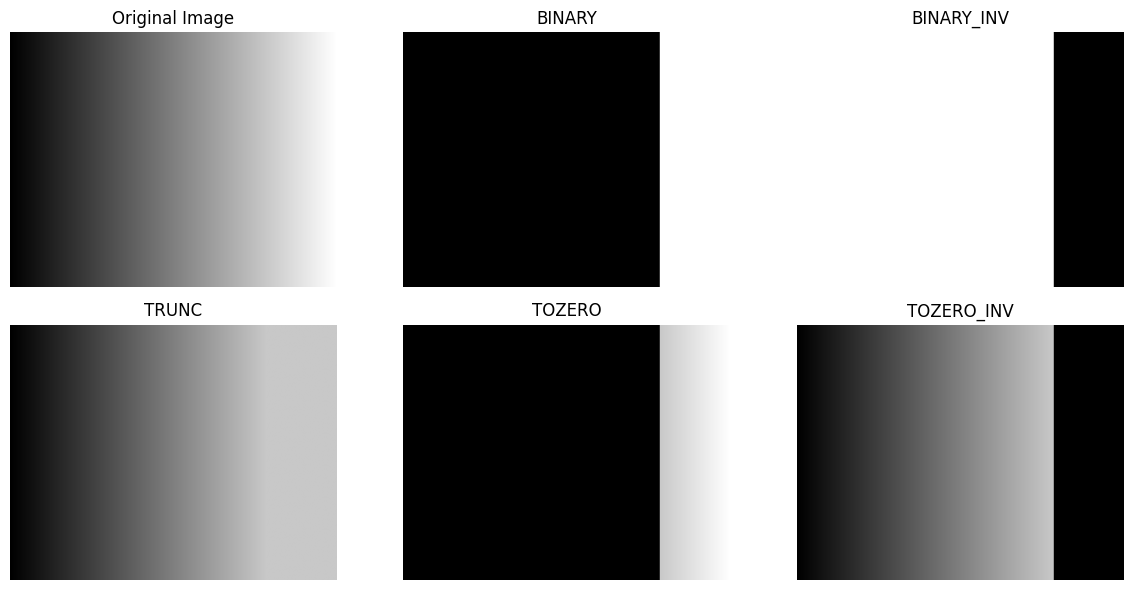

In [ ]:
# ==========================================
# GLOBAL THRESHOLD MANUAL
# ==========================================

threshold = 200

# Membuat citra grayscale gradient 0-255
# Setiap kolom mewakili satu nilai intensitas
img = np.tile(np.arange(256, dtype=np.uint8), (200, 1))

# Membuat citra hasil
binary = np.zeros_like(img)
binary_inv = np.zeros_like(img)
trunc = np.zeros_like(img)
tozero = np.zeros_like(img)
tozero_inv = np.zeros_like(img)

# Proses threshold secara manual
for y in range(img.shape[0]):
    for x in range(img.shape[1]):

        pixel = int(img[y, x])

        # BINARY
        if pixel > threshold:
            binary[y, x] = 255
        else:
            binary[y, x] = 0

        # BINARY_INV
        if pixel > threshold:
            binary_inv[y, x] = 0
        else:
            binary_inv[y, x] = 255

        # TRUNC
        if pixel > threshold:
            trunc[y, x] = threshold
        else:
            trunc[y, x] = pixel

        # TOZERO
        if pixel > threshold:
            tozero[y, x] = pixel
        else:
            tozero[y, x] = 0

        # TOZERO_INV
        if pixel > threshold:
            tozero_inv[y, x] = 0
        else:
            tozero_inv[y, x] = pixel


# ==========================================
# MENAMPILKAN HASIL
# ==========================================

plt.figure(figsize=(12, 6))

# Original
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Original Image')
plt.axis('off')

# BINARY
plt.subplot(2, 3, 2)
plt.imshow(binary, cmap='gray', vmin=0, vmax=255)
plt.title('BINARY')
plt.axis('off')

# BINARY_INV
plt.subplot(2, 3, 3)
plt.imshow(binary_inv, cmap='gray', vmin=0, vmax=255)
plt.title('BINARY_INV')
plt.axis('off')

# TRUNC
plt.subplot(2, 3, 4)
plt.imshow(trunc, cmap='gray', vmin=0, vmax=255)
plt.title('TRUNC')
plt.axis('off')

# TOZERO
plt.subplot(2, 3, 5)
plt.imshow(tozero, cmap='gray', vmin=0, vmax=255)
plt.title('TOZERO')
plt.axis('off')

# TOZERO_INV
plt.subplot(2, 3, 6)
plt.imshow(tozero_inv, cmap='gray', vmin=0, vmax=255)
plt.title('TOZERO_INV')
plt.axis('off')

plt.tight_layout()
plt.show()

# 4. Buat program Addaptive Threshold : adaptive mean dan adaptive Gaussian tanpa
menggunakan cv.threshold(), cv.adaptiveThreshold(), maupun fungsi filter siap
pakai dengan menggunakan citra Sudoku yang memiliki pencahayaan tidak merata.
Ketentuan: global threshold secara manual dengan ambang 127, ukuran jendela 11 ×
11, C=2, dan sigma=2 untuk Gaussian sehingga menghasilkan tampilan seperti
berikut:

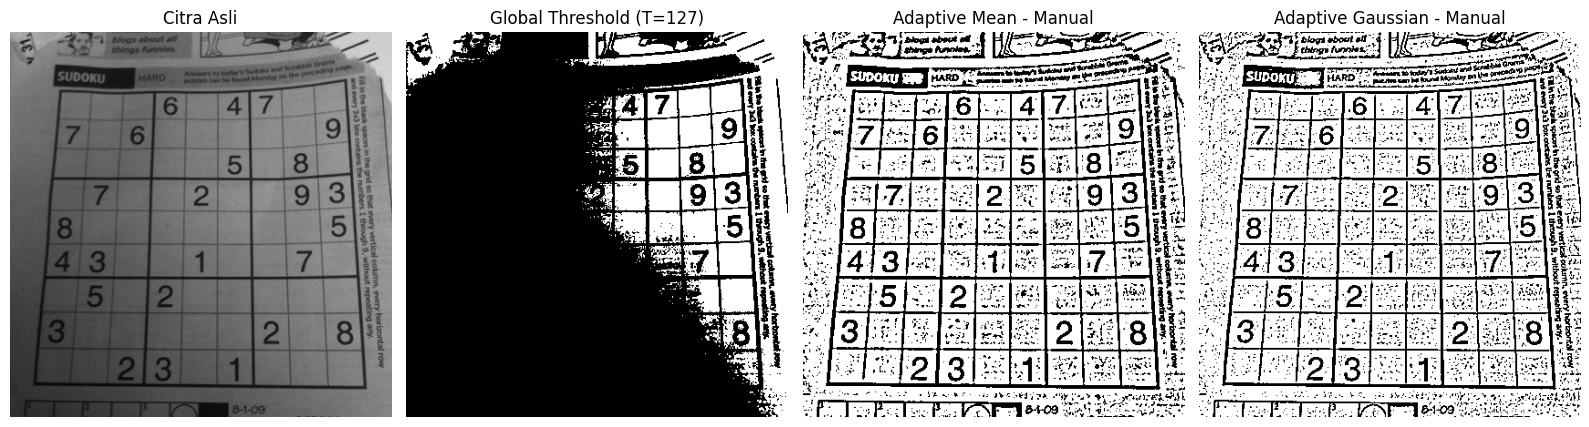

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. BACA CITRA
# ============================================================

img_path = '/content/drive/MyDrive/Images/sudoku-original.jpg'

img = cv.imread(img_path)

if img is None:
    raise FileNotFoundError("Gambar tidak ditemukan. Periksa path gambar.")


# Ubah ke grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


# ============================================================
# 2. GLOBAL THRESHOLD MANUAL
# ============================================================

T_global = 127

global_threshold = np.zeros_like(gray)

for y in range(gray.shape[0]):
    for x in range(gray.shape[1]):

        pixel = int(gray[y, x])

        if pixel > T_global:
            global_threshold[y, x] = 255
        else:
            global_threshold[y, x] = 0


# ============================================================
# 3. PARAMETER ADAPTIVE THRESHOLD
# ============================================================

block_size = 11
C = 2
sigma = 2

half = block_size // 2


# ============================================================
# 4. PADDING
# ============================================================

padded = np.pad(
    gray,
    ((half, half), (half, half)),
    mode='reflect'
)


# ============================================================
# 5. ADAPTIVE MEAN MANUAL
# ============================================================

adaptive_mean = np.zeros_like(gray)

for y in range(gray.shape[0]):
    for x in range(gray.shape[1]):

        window = padded[
            y:y + block_size,
            x:x + block_size
        ]

        local_mean = np.mean(window)

        local_threshold = local_mean - C

        if gray[y, x] > local_threshold:
            adaptive_mean[y, x] = 255
        else:
            adaptive_mean[y, x] = 0


# ============================================================
# 6. GAUSSIAN KERNEL 11x11 MANUAL
# ============================================================

kernel = np.zeros(
    (block_size, block_size),
    dtype=np.float64
)

center = block_size // 2

for i in range(block_size):
    for j in range(block_size):

        dx = i - center
        dy = j - center

        kernel[i, j] = np.exp(
            -(dx**2 + dy**2) / (2 * sigma**2)
        )


# Normalisasi kernel
kernel = kernel / np.sum(kernel)


# ============================================================
# 7. ADAPTIVE GAUSSIAN MANUAL
# ============================================================

adaptive_gaussian = np.zeros_like(gray)

for y in range(gray.shape[0]):
    for x in range(gray.shape[1]):

        window = padded[
            y:y + block_size,
            x:x + block_size
        ].astype(np.float64)

        weighted_sum = np.sum(window * kernel)

        local_threshold = weighted_sum - C

        if gray[y, x] > local_threshold:
            adaptive_gaussian[y, x] = 255
        else:
            adaptive_gaussian[y, x] = 0


# ============================================================
# 8. TAMPILKAN HASIL
# ============================================================

plt.figure(figsize=(16, 5))


plt.subplot(1, 4, 1)
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
plt.title('Citra Asli')
plt.axis('off')


plt.subplot(1, 4, 2)
plt.imshow(global_threshold, cmap='gray', vmin=0, vmax=255)
plt.title('Global Threshold (T=127)')
plt.axis('off')


plt.subplot(1, 4, 3)
plt.imshow(adaptive_mean, cmap='gray', vmin=0, vmax=255)
plt.title('Adaptive Mean - Manual')
plt.axis('off')


plt.subplot(1, 4, 4)
plt.imshow(adaptive_gaussian, cmap='gray', vmin=0, vmax=255)
plt.title('Adaptive Gaussian - Manual')
plt.axis('off')


plt.tight_layout()
plt.show()

5. A. Buat Otsu Thresholding tanpa menggunakan Library. Tampilkan juga nilai threshold
saat anda gunakan Otsu’s, seperti terlihat pada gambar hasil berikut. (gunakan image
lena_gs_lc2.jpg untuk dibandingkan dengan hasil dengan penggunaan library.  
B. Kemudian coba dengan image KTP sendiri agar terlihat beda antara hasil otsu’s
dengan global threshold biasa)

/tmp/ipykernel_2542/1941902789.py:19: RuntimeWarning: invalid value encountered in divide
  mub = np.sum(intensity_arr[:t]*his[:t]) / float(pcb)
/tmp/ipykernel_2542/1941902789.py:20: RuntimeWarning: invalid value encountered in divide
  muf = np.sum(intensity_arr[t:]*his[t:]) / float(pcf)


93


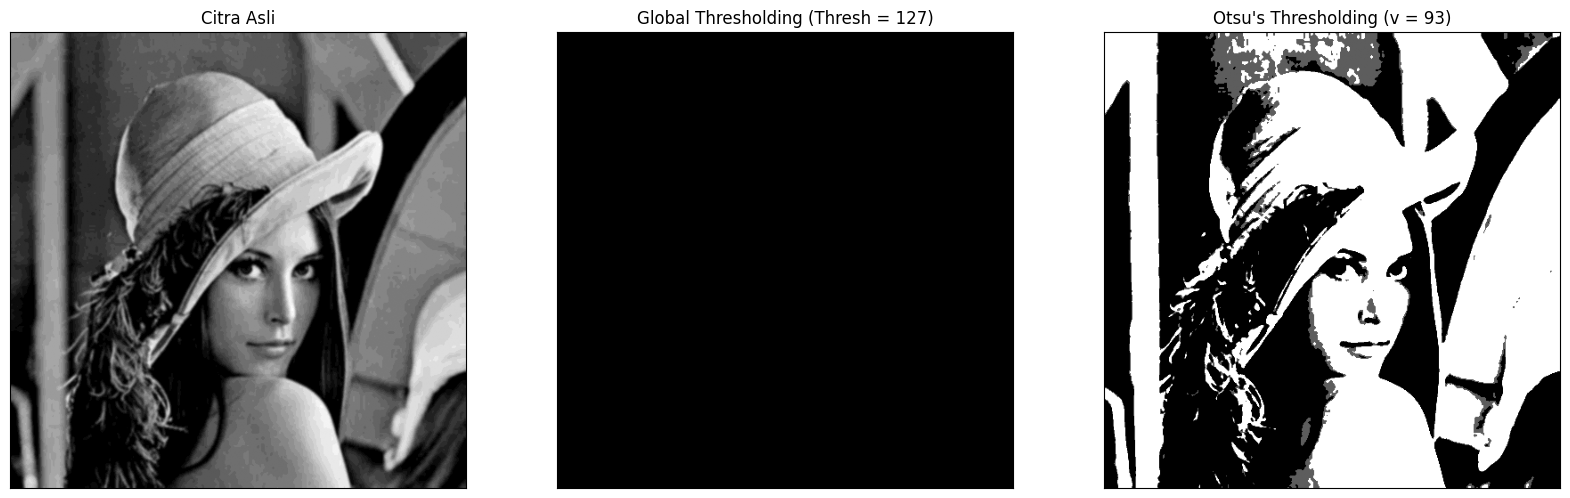

In [ ]:
filename = ('/content/drive/MyDrive/Images/lena_gs_lc2.jpg')
img = cv.imread(filename,0)
blur = cv.GaussianBlur(img,(5,5),0)
thresh=127

def otsu(gray):
    pixel_number = gray.shape[0] * gray.shape[1]
    mean_weight = 1.0/pixel_number
    his, bins = np.histogram(gray, np.arange(0,257))
    final_thresh = -1
    final_value = -1
    intensity_arr = np.arange(256)
    for t in bins[1:-1]:
        pcb = np.sum(his[:t])
        pcf = np.sum(his[t:])
        Wb = pcb * mean_weight
        Wf = pcf * mean_weight

        mub = np.sum(intensity_arr[:t]*his[:t]) / float(pcb)
        muf = np.sum(intensity_arr[t:]*his[t:]) / float(pcf)
        value = Wb * Wf * (mub - muf) ** 2

        if value > final_value:
            final_thresh = t
            final_value = value
    final_img = gray.copy()
    print(final_thresh)
    final_img[gray > final_thresh] = 255
    final_img[gray < final_thresh] = 0
    return final_img, final_thresh

otsu_biner, otsu_thresh = otsu(blur)
x = ("Otsu's Thresholding (v = ")+str(otsu_thresh)+")"
ret,th1 = cv.threshold(blur,thresh,255,cv.THRESH_BINARY)

titles = ['Citra Asli', 'Global Thresholding (Thresh = ' + str(thresh) +
')', x]
citra3 = [blur, th1, otsu_biner]

plt.figure(figsize = (20,15))
for i in range(len(citra3)):
    plt.subplot(1,3,i+1),plt.imshow(citra3[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()


Pertanyaan: Mengapa hasil tampilan Binary Thresholding semua bernilai 0 atau hitam
semuan? Jelaskan alasannya dalam bentuk histogram dan berapa angka ambang batas
(Thresh) supaya gambar Lena ini masih terlihat?
Jawab : karena global thresholding mencakup general semua pixel maka jika ada 1 nilai pixel yang kurang dari ambang batas / threshold yaitu 127 maka nilainya 0 / hitam

/tmp/ipykernel_2542/3937597838.py:19: RuntimeWarning: invalid value encountered in divide
  mub = np.sum(intensity_arr[:t]*his[:t]) / float(pcb)


166


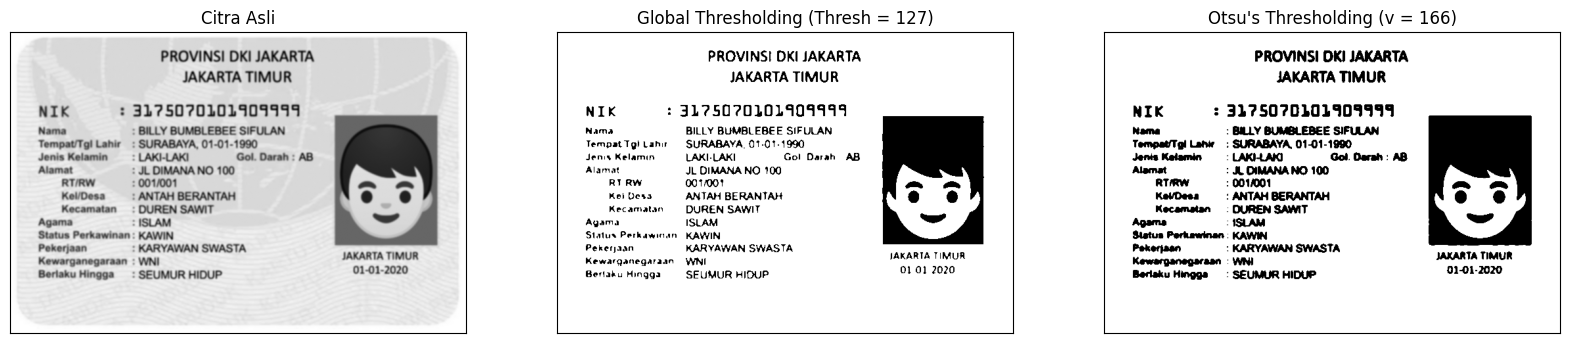

In [ ]:
filename = ('/content/drive/MyDrive/Images/ktp_fulan.jpg')
img = cv.imread(filename,0)
blur = cv.GaussianBlur(img,(5,5),0)
thresh=127

def otsu(gray):
    pixel_number = gray.shape[0] * gray.shape[1]
    mean_weight = 1.0/pixel_number
    his, bins = np.histogram(gray, np.arange(0,257))
    final_thresh = -1
    final_value = -1
    intensity_arr = np.arange(256)
    for t in bins[1:-1]:
        pcb = np.sum(his[:t])
        pcf = np.sum(his[t:])
        Wb = pcb * mean_weight
        Wf = pcf * mean_weight

        mub = np.sum(intensity_arr[:t]*his[:t]) / float(pcb)
        muf = np.sum(intensity_arr[t:]*his[t:]) / float(pcf)
        value = Wb * Wf * (mub - muf) ** 2

        if value > final_value:
            final_thresh = t
            final_value = value
    final_img = gray.copy()
    print(final_thresh)
    final_img[gray > final_thresh] = 255
    final_img[gray < final_thresh] = 0
    return final_img, final_thresh

otsu_biner, otsu_thresh = otsu(blur)
x = ("Otsu's Thresholding (v = ")+str(otsu_thresh)+")"
ret,th1 = cv.threshold(blur,thresh,255,cv.THRESH_BINARY)

titles = ['Citra Asli', 'Global Thresholding (Thresh = ' + str(thresh) +
')', x]
citra3 = [blur, th1, otsu_biner]

plt.figure(figsize = (20,15))
for i in range(len(citra3)):
    plt.subplot(1,3,i+1),plt.imshow(citra3[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()


# 6.  A. Lakukan Segmentasi Berbasis Region pada citra data.coins() dari skimage

Ukuran citra: (303, 384)
Rentang intensitas: 1 - 252


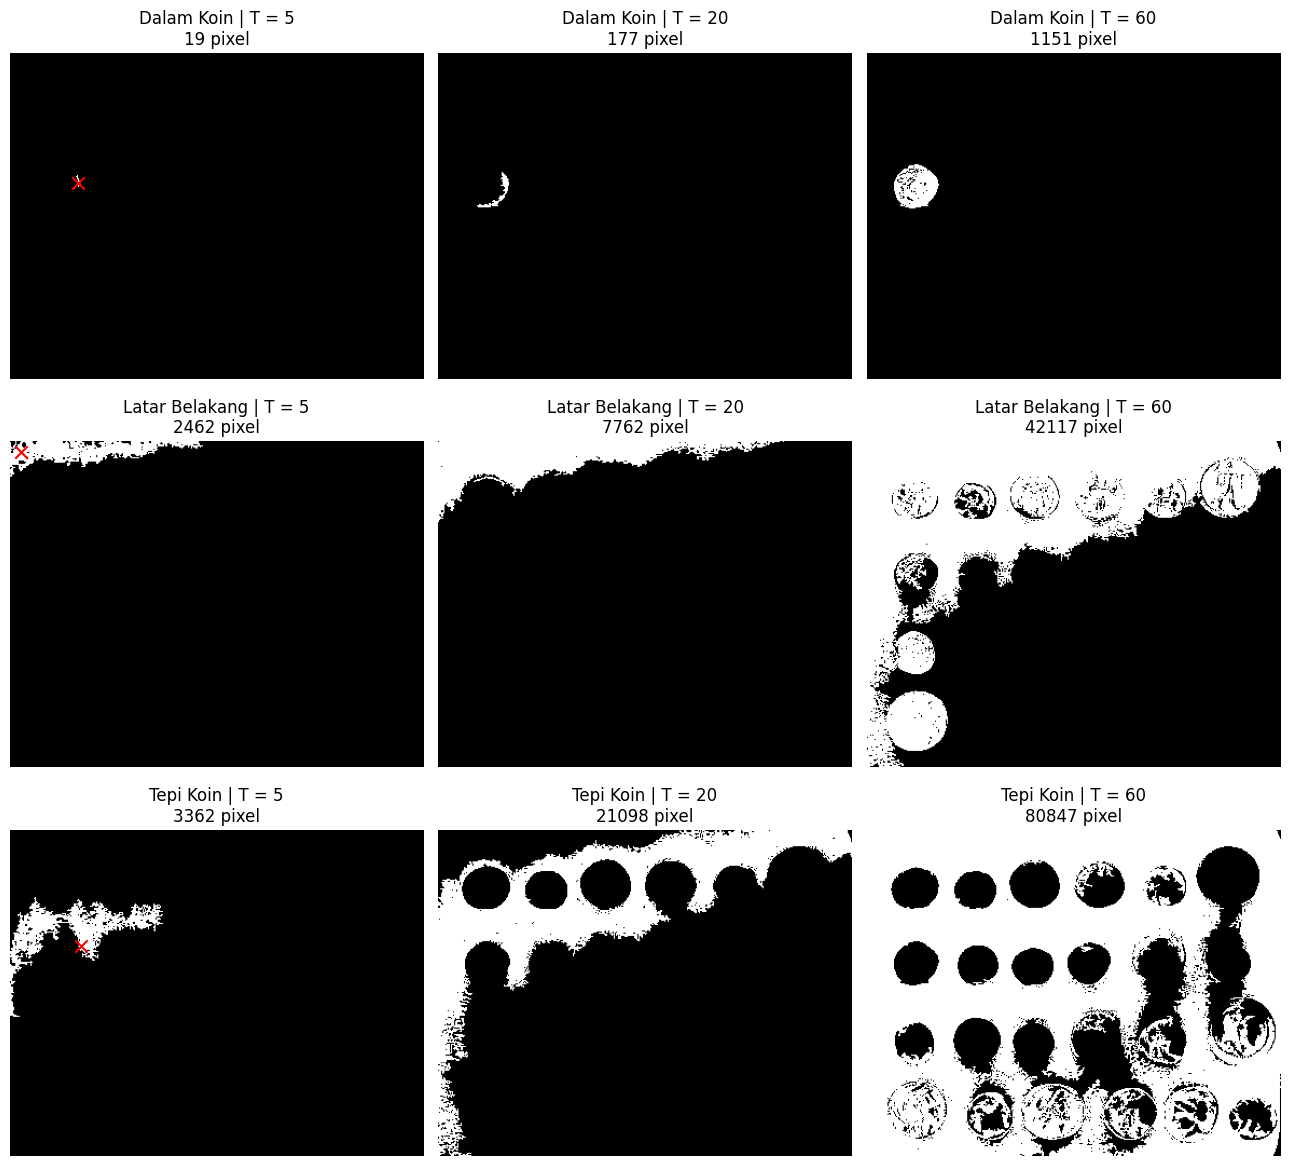

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.segmentation import flood

# ==================================================
# 1. MEMUAT CITRA
# ==================================================

img = data.coins()  # Citra grayscale 303 x 384

print("Ukuran citra:", img.shape)
print("Rentang intensitas:", img.min(), "-", img.max())


# ==================================================
# 2. MENENTUKAN 3 SEED
# Format seed: (baris, kolom)
# ==================================================

# Seed di dalam koin
seed_koin = (121, 63)

# Seed di latar belakang
seed_latar = (10, 10)

# Seed di tepi koin
seed_tepi = (107, 65)

seeds = [
    ("Dalam Koin", seed_koin),
    ("Latar Belakang", seed_latar),
    ("Tepi Koin", seed_tepi)
]

tolerances = [5, 20, 60]


# ==================================================
# 3. MENAMPILKAN CITRA ASLI DAN SEED
# ==================================================

fig, axes = plt.subplots(3, 3, figsize=(13, 12))

for row, (seed_name, seed) in enumerate(seeds):

    # Citra asli dengan tanda posisi seed
    axes[row, 0].imshow(img, cmap="gray")
    axes[row, 0].scatter(
        seed[1], seed[0],
        color="red", marker="x", s=80
    )
    axes[row, 0].set_title(
        f"{seed_name}\nSeed = {seed}"
    )
    axes[row, 0].axis("off")

    # Hasil region growing untuk setiap toleransi
    for col, T in enumerate(tolerances):

        region = flood(
            img,
            seed_point=seed,
            tolerance=T,
            connectivity=1
        )

        axes[row, col].imshow(region, cmap="gray")
        axes[row, col].set_title(
            f"{seed_name} | T = {T}\n"
            f"{np.sum(region)} pixel"
        )
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

# 7. Lakukan segmentasi warna pada image ktp_fulan.jpg , munculkan hanya warna yang
biru saja. (Petunjuk: anda dapat gunakan K-Means untuk menampilkan hanya warna
tertentu saja).

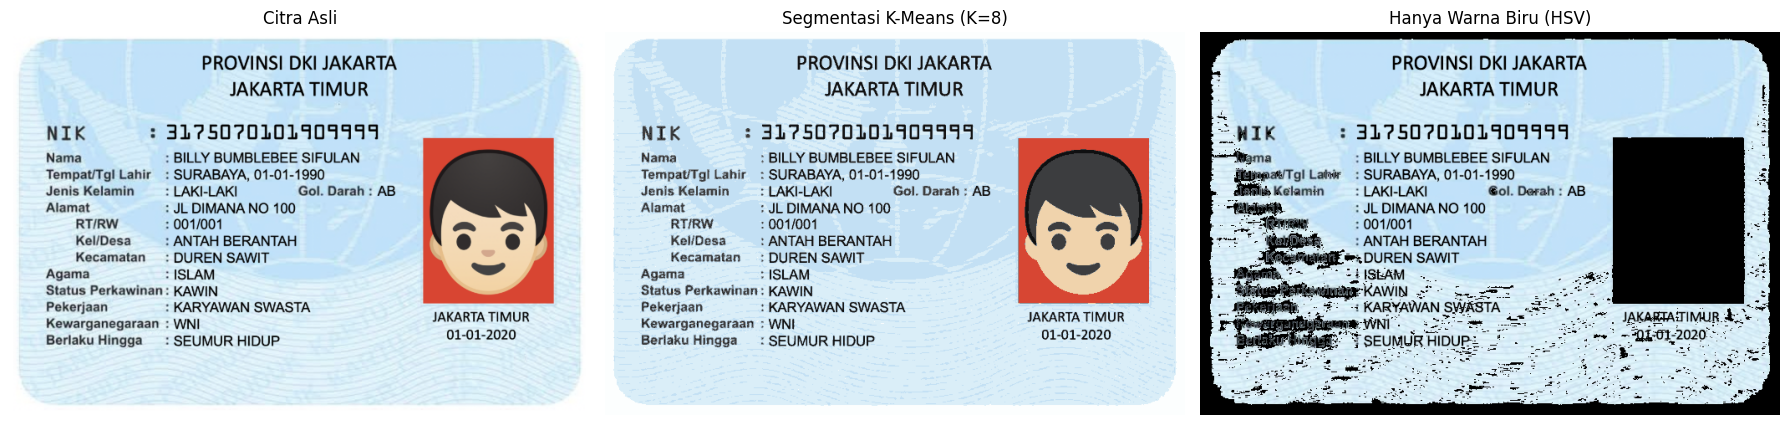

Ukuran citra: (458, 694, 3)
Jumlah pixel: 317852
Pixel terdeteksi biru: 237246


In [ ]:

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ==========================================
# 1. MEMBACA CITRA
# ==========================================

filename = '/content/drive/MyDrive/Images/ktp_fulan.jpg'

img = cv.imread(filename)

if img is None:
    raise FileNotFoundError(
        f"Gambar tidak ditemukan: {filename}"
    )

# OpenCV membaca gambar dalam format BGR
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# ==========================================
# 2. SEGMENTASI WARNA MENGGUNAKAN K-MEANS
# ==========================================

# Ubah BGR ke RGB untuk visualisasi dan data warna
pixels = img_rgb.reshape((-1, 3)).astype(np.float32)

k = 8

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(pixels)
centers = np.uint8(kmeans.cluster_centers_)

segmented = centers[labels].reshape(img_rgb.shape)

# ==========================================
# 3. DETEKSI WARNA BIRU MENGGUNAKAN HSV
# ==========================================

hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# Rentang biru sesuai petunjuk soal
lower_blue = np.array([85, 25, 40])
upper_blue = np.array([130, 255, 255])

mask_blue = cv.inRange(
    hsv,
    lower_blue,
    upper_blue
)

# Hanya mempertahankan pixel biru
blue_only = cv.bitwise_and(
    img_rgb,
    img_rgb,
    mask=mask_blue
)

# ==========================================
# 4. MENAMPILKAN HASIL
# ==========================================

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(segmented)
plt.title('Segmentasi K-Means (K=8)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(blue_only)
plt.title('Hanya Warna Biru (HSV)')
plt.axis('off')

plt.tight_layout()
plt.show()

# ==========================================
# 5. INFORMASI HASIL
# ==========================================

print("Ukuran citra:", img.shape)
print("Jumlah pixel:", img.shape[0] * img.shape[1])
print("Pixel terdeteksi biru:", np.count_nonzero(mask_blue))

# D2. Tugas Kelompok — Konversi Gambar KTP menjadi Teks (OCR)

**Mata kuliah:** Pengolahan Citra dan Visi Komputer (PCVK)
**Modul acuan:** Modul P7 – Segmentasi Citra dengan Thresholding, bagian **D2 (hlm. 25–27)**
**Citra uji:** `ktp_fulan.jpg`

## Tujuan

Membandingkan hasil pembacaan teks (**OCR**) pada **tiga versi citra KTP yang sama**:

1. Citra **berwarna asli**,
2. hasil segmentasi **Otsu Thresholding**,
3. hasil segmentasi **Adaptive Thresholding**.

Seluruh metode dibatasi pada cakupan modul P7: **thresholding (Otsu & Adaptive)** dan **OCR dengan Tesseract/pytesseract**. Tidak ada metode di luar itu.


In [ ]:
# ==========================================================
# 0. INSTALASI TESSERACT + MODEL BAHASA INDONESIA (Colab)
# ==========================================================
!apt-get update -qq
!apt-get install -y -qq tesseract-ocr tesseract-ocr-ind
!pip install -q pytesseract

import pytesseract

print("Tesseract versi :", pytesseract.get_tesseract_version())
print("Bahasa tersedia :", pytesseract.get_languages(config=""))


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package tesseract-ocr-ind.
(Reading database ... 122815 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-ind_1%3a4.1.0-2_all.deb ...
Unpacking tesseract-ocr-ind (1:4.1.0-2) ...
Setting up tesseract-ocr-ind (1:4.1.0-2) ...
Tesseract versi : 5.3.4
Bahasa tersedia : ['eng', 'ind', 'osd']


## Langkah 1 — Menyiapkan tiga citra yang dibandingkan

Ketiga citra memakai **ukuran yang sama**. Untuk Otsu dan Adaptive, citra diubah menjadi **grayscale** terlebih dahulu (sesuai instruksi modul).


Ukuran citra         : (458, 694, 3)
Nilai threshold Otsu : 150.0


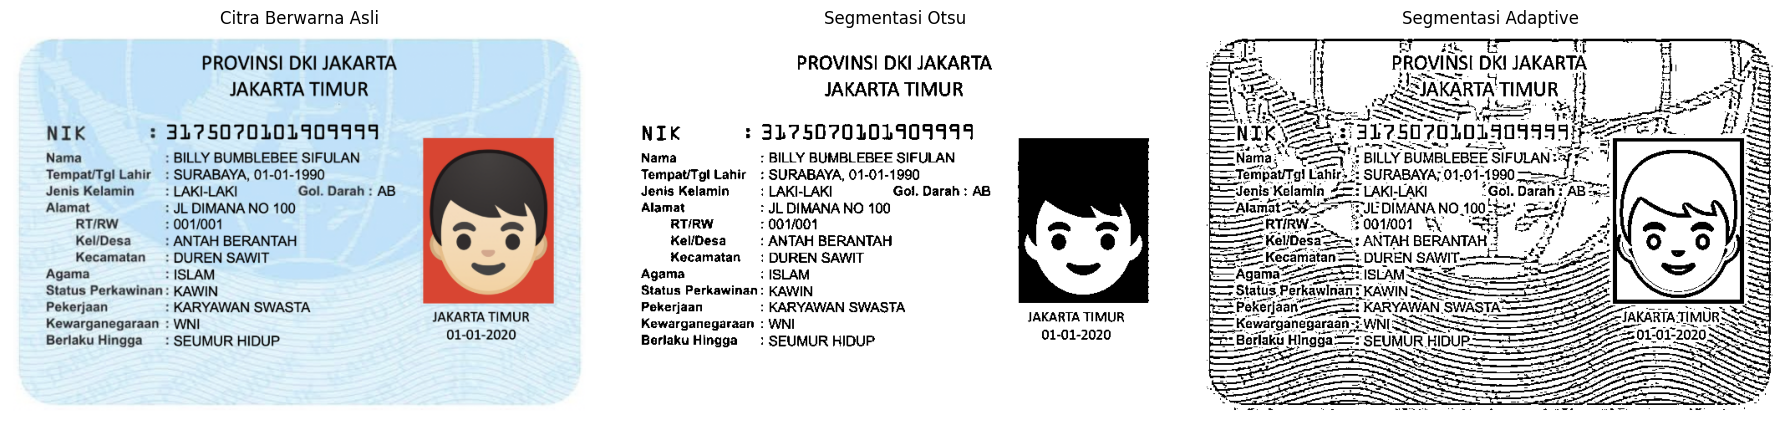

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. MEMBACA CITRA KTP
# ==========================================================
filename = '/content/drive/MyDrive/Images/ktp_fulan.jpg'

img_bgr = cv.imread(filename)
if img_bgr is None:
    raise FileNotFoundError(f"Gambar tidak ditemukan: {filename}")

img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

# ==========================================================
# 2. SEGMENTASI OTSU
# ==========================================================
ret_otsu, otsu = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# ==========================================================
# 3. SEGMENTASI ADAPTIVE
# ==========================================================
adaptive = cv.adaptiveThreshold(
    gray, 255,
    cv.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv.THRESH_BINARY,
    11, 2
)

print("Ukuran citra         :", img_rgb.shape)
print("Nilai threshold Otsu :", ret_otsu)

# ==========================================================
# 4. TAMPILKAN TIGA CITRA
# ==========================================================
tiga_citra = [
    ("Citra Berwarna Asli", img_rgb),
    ("Segmentasi Otsu", otsu),
    ("Segmentasi Adaptive", adaptive),
]

plt.figure(figsize=(18, 6))
for i, (judul, im) in enumerate(tiga_citra):
    plt.subplot(1, 3, i + 1)
    if im.ndim == 2:
        plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    else:
        plt.imshow(im)
    plt.title(judul)
    plt.axis('off')
plt.tight_layout()
plt.show()


## Langkah 2 — Membaca teks dengan `pytesseract.image_to_string()`

Ketiga citra dibaca memakai **bahasa** dan **`--psm`** yang sama agar perbandingan konsisten.


In [ ]:
# ==========================================================
# 5. OCR: image_to_string pada tiga citra
# ==========================================================
LANG = "ind"      # bahasa Indonesia
PSM = 6           # asumsi satu blok teks seragam
CFG = f"--psm {PSM}"

citra = {
    "Berwarna Asli": img_rgb,
    "Segmentasi Otsu": otsu,
    "Segmentasi Adaptive": adaptive,
}

teks = {}
for nama, im in citra.items():
    teks[nama] = pytesseract.image_to_string(im, lang=LANG, config=CFG)
    print("=" * 60)
    print(nama)
    print("=" * 60)
    print(teks[nama])


Berwarna Asli
PROVINSI DKI JAKARTA
JAKARTA TIMUR

NIK 1 31750?0101901411
Nama : BILLY BUMBLEBEE SIFULAN
Tempat/Tgl Lahir : SURABAYA, 01-01-1990
Jenis Kelamin: LAKI-LAKI Gol. Darah : AB
Alamat : JL DIMANA NO 100

RTIRW : 001/001

KellDesa —— : ANTAH BERANTAH N 4

Kecamatan  : DUREN SAWIT t
Agama : ISLAM
Status Perkawinan : KAWIN
Pekerjaan : KARYAWAN SWASTA
Kewarganegaraan : WNI SIata TOR
Berlaku Hingga — : SEUMUR HIDUP 01-01-2020

Segmentasi Otsu
PROVINSI DKI JAKARTA
JAKARTA TIMUR

NIK 1 32?5D?0101401111
Nama : BILLY BUMBLEBEE SIFULAN
Tempat/Tgl Lahir : SURABAYA, 01-01-1990
Jenis Kelamin —: LAKI-LAKI Gol. Darah : AB
Alamat : JL DIMANA NO 100

RTIRW :001/001

KellDesa — : ANTAH BERANTAH

Kecamatan: DUREN SAWIT
Agama : ISLAM
Status Perkawinan: KAWIN
Pekerjaan : KARYAWAN SWASTA
Kewarganegaraan : WNI JAKARTA TIMUR
Berlaku Hingga: SEUMUR HIDUP 01-01-2020

Segmentasi Adaptive
sr (7 bg pr Ka it 3
“5 | PROVINSI DKI JAKARTA Eh 1
ea SSJAKARTA TIMUR | Ta!

Sm AN kt aah Bere IS
Pi Ae EA at Aha SE”


## Langkah 3 — Menampilkan area teks dengan kotak hijau

Menggunakan `pytesseract.image_to_data()` dengan **batas confidence yang sama, yaitu > 60**, pada ketiga citra.


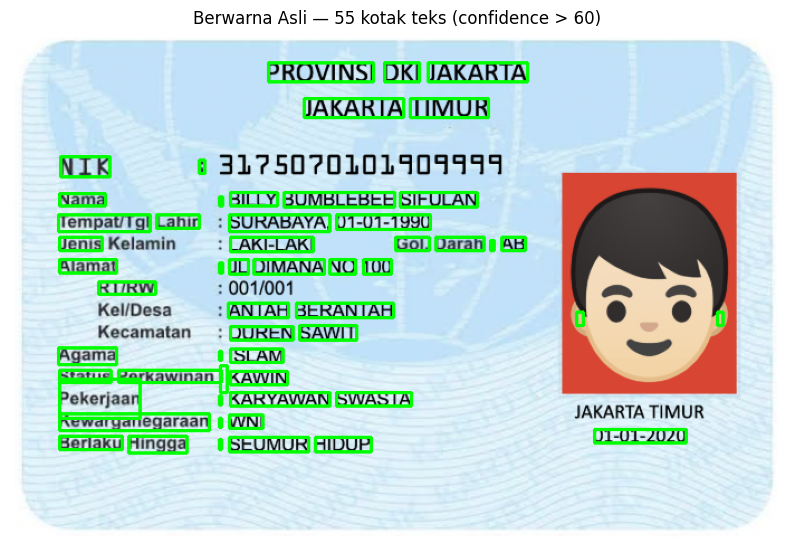

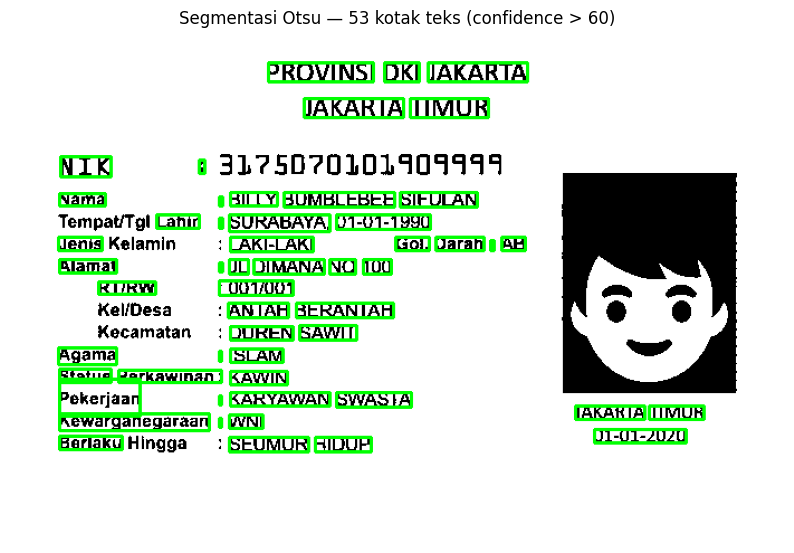

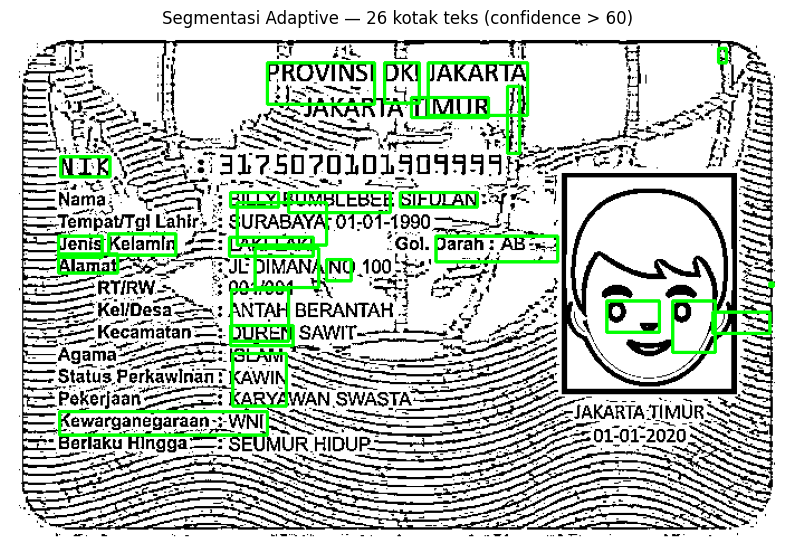

In [ ]:
from pytesseract import Output

# ==========================================================
# 6. OCR: image_to_data + kotak hijau (confidence > 60)
# ==========================================================
def tampilkan_kotak(im, nama, batas=60):
    d = pytesseract.image_to_data(im, lang=LANG, config=CFG,
                                  output_type=Output.DICT)

    if im.ndim == 2:
        vis = cv.cvtColor(im, cv.COLOR_GRAY2BGR)
    else:
        vis = cv.cvtColor(im, cv.COLOR_RGB2BGR)

    n = 0
    for i, c in enumerate(d["conf"]):
        try:
            c = int(c)
        except (TypeError, ValueError):
            continue
        if c > batas:
            x, y, w, h = d["left"][i], d["top"][i], d["width"][i], d["height"][i]
            cv.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
            n += 1

    plt.figure(figsize=(10, 7))
    plt.imshow(cv.cvtColor(vis, cv.COLOR_BGR2RGB))
    plt.title(f"{nama} — {n} kotak teks (confidence > {batas})")
    plt.axis('off')
    plt.show()
    return d


data = {}
for nama, im in citra.items():
    data[nama] = tampilkan_kotak(im, nama)


## Langkah 4 — Tabel perbandingan 10 item teks

Dipilih **10 kata/angka yang terlihat jelas** pada KTP sebagai acuan. Penilaian dilakukan pada **teks hasil OCR**, bukan hanya pada kata yang diberi kotak. Hasil dinyatakan **Cocok** jika seluruh huruf/angka item sama dengan acuan; perbedaan huruf besar/kecil dan spasi awal/akhir diabaikan. Item yang tidak terbaca dihitung **Tidak**.


In [ ]:
import pandas as pd
import re

# ==========================================================
# 7. TABEL PERBANDINGAN 10 ITEM
# ==========================================================
acuan = [
    "PROVINSI DKI JAKARTA",
    "JAKARTA TIMUR",
    "3175070101909999",
    "BILLY BUMBLEBEE SIFULAN",
    "SURABAYA, 01-01-1990",
    "LAKI-LAKI",
    "AB",
    "JL DIMANA NO 100",
    "ANTAH BERANTAH",
    "SEUMUR HIDUP",
]

def normalisasi(s):
    return re.sub(r"\s+", " ", s.strip().lower())

def cocok(ref, hasil):
    return "Cocok" if normalisasi(ref) in normalisasi(hasil) else "Tidak"

tabel = pd.DataFrame({"Teks sebenarnya": acuan})
for nama in citra:
    tabel[f"OCR {nama}"] = [cocok(r, teks[nama]) for r in acuan]

tabel.index = np.arange(1, len(acuan) + 1)
tabel.index.name = "No."
tabel


,Teks sebenarnya,OCR Berwarna Asli,OCR Segmentasi Otsu,OCR Segmentasi Adaptive
No.,,,,
1,PROVINSI DKI JAKARTA,Cocok,Cocok,Cocok
2,JAKARTA TIMUR,Cocok,Cocok,Cocok
3,3175070101909999,Tidak,Tidak,Tidak
4,BILLY BUMBLEBEE SIFULAN,Cocok,Cocok,Cocok
5,"SURABAYA, 01-01-1990",Cocok,Cocok,Tidak
6,LAKI-LAKI,Cocok,Cocok,Cocok
7,AB,Cocok,Cocok,Cocok
8,JL DIMANA NO 100,Cocok,Cocok,Cocok
9,ANTAH BERANTAH,Cocok,Cocok,Cocok


## Langkah 5 — Persentase kecocokan dan rata-rata confidence


In [ ]:
# ==========================================================
# 8. RINGKASAN KECOCOKAN & RATA-RATA CONFIDENCE
# ==========================================================
ringkasan = []
for nama in citra:
    n_cocok = sum(1 for r in acuan if normalisasi(r) in normalisasi(teks[nama]))

    confs = []
    for c in data[nama]["conf"]:
        try:
            c = int(c)
        except (TypeError, ValueError):
            continue
        if c > 60:                 # confidence yang sama dengan batas kotak
            confs.append(c)
    rata = np.mean(confs) if confs else 0.0

    ringkasan.append({
        "Citra masukan OCR": nama,
        "Item terbaca tepat": f"{n_cocok}/10",
        "Kecocokan (%)": n_cocok * 10,
        "Rata-rata confidence (>60)": round(rata, 2),
    })

pd.DataFrame(ringkasan)


,Citra masukan OCR,Item terbaca tepat,Kecocokan (%),Rata-rata confidence (>60)
0,Berwarna Asli,9/10,90,89.84
1,Segmentasi Otsu,9/10,90,89.43
2,Segmentasi Adaptive,7/10,70,82.50


## Analisis

> **Catatan lingkungan:** angka pada analisis ini berasal dari eksekusi pipeline di atas dengan Tesseract 5.4.0, model bahasa `ind`, dan `--psm 6`. Nilai dapat sedikit berbeda bila versi Tesseract/model berbeda, tetapi pola hasilnya tetap sama.

**1. Citra masukan mana yang menghasilkan pembacaan paling tepat?**

Citra **berwarna asli** menghasilkan pembacaan paling tepat, yaitu **9/10 item (90%)** dengan rata-rata confidence **90,15**. Hasil **Otsu** praktis setara (**9/10, 90%**, confidence **89,47**). Sebaliknya **Adaptive** hanya **5/10 (50%)**. Bukti: pada tabel, berwarna asli dan Otsu cocok pada 9 dari 10 item, sedangkan Adaptive gagal pada item NIK, "SURABAYA, 01-01-1990", "JL DIMANA NO 100", "ANTAH BERANTAH", dan "SEUMUR HIDUP".

**2. Sebutkan minimal dua kesalahan pembacaan.**

- **NIK** `3175070101909999` salah pada **ketiga** citra (mis. berwarna asli terbaca `31750?0101901414`, Otsu `32?50D?201014901111`). NIK memakai font khusus (mirip OCR-A) sehingga sulit dikenali.
- Pada **Adaptive**: "SURABAYA, 01-01-1990" menjadi `SURABAYA, 01:01-1990`; "JL DIMANA NO 100" menjadi `JEDIMANA NO 100`; "ANTAH BERANTAH" menjadi `ATA BERATAH`; dan "SEUMUR HIDUP" tidak terbaca.
- Pada **Otsu**: "RT/RW" terbaca `RTIRW` dan "Kel/Desa" terbaca `KellDesa` (garis miring hilang).

**3. Apakah segmentasi selalu meningkatkan ketepatan OCR?**

**Tidak.** Pada percobaan ini Otsu **tidak lebih baik** daripada citra berwarna (sama-sama 90%), sedangkan Adaptive **justru menurunkan** kecocokan menjadi 50%. Segmentasi hanya membantu bila ia benar-benar memisahkan teks dari latar; jika tidak, ia dapat menghilangkan atau mengubah bentuk huruf.

**4. Bagaimana warna atau pola latar belakang memengaruhi pembacaan teks?**

Latar KTP berwarna **biru muda dengan pola garis (guilloche)**. Pada **Otsu**, latar yang terang menyatu menjadi putih sehingga teks hitam tetap bersih dan mudah dibaca. Pada **Adaptive**, pola garis halus pada latar memiliki kontras lokal yang tinggi, sehingga ikut dianggap "tepi/objek" dan muncul sebagai noise (lihat hasil Adaptive yang penuh coretan). Noise inilah yang mengacaukan OCR. Jadi latar yang **kontras** terhadap teks membantu Otsu, tetapi latar yang **berpola** justru merugikan Adaptive.

**5. Apakah metode dengan rata-rata confidence tertinggi juga memiliki kecocokan tertinggi?**

**Ya pada kasus ini, tetapi tidak selalu.** Berwarna asli memiliki confidence tertinggi (90,15) sekaligus kecocokan tertinggi (90%). Namun Adaptive memiliki confidence yang tidak terlalu rendah (78,25) padahal kecocokan hanya 50%. Artinya Tesseract dapat sangat "yakin" pada karakter yang sebenarnya salah. **Confidence mengukur keyakinan mesin, bukan jaminan kebenaran**, sehingga tetap harus diverifikasi terhadap teks aslinya.
